In [1]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
from scipy.optimize import minimize
import pickle
from matplotlib.colors import LinearSegmentedColormap
import os

In [2]:
sam_cj = SAM()
sam_cj.load_data('../../Active_SAM_joined/SAM_CJ_joined_v2_cleaned_03122025.h5ad')

sam_ac = SAM()
sam_ac.load_data('../../Active_SAM_joined/SAM_AC_ncbi_soupx_cleaned_03122025.h5ad')

sam_xt = SAM()
sam_xt.load_data('../../Active_SAM_joined/SAM_XT_joined_Slc17a6_cleaned_03122205.h5ad')

sam_dr = SAM()
sam_dr.load_data('../../Active_SAM_joined/SAM_DR_ncbi_joined_cleaned_07172026.h5ad')

In [3]:
sam_xt.adata.obs.columns

Index(['n_genes', 'n_counts', 'key', 'leiden_clusters', 'eq_subclass',
       'eq_subclass_lc', 'eq_subclass_frac', 'eq_subclass_nounlabeled',
       'eq_subclass_nounlabeled_NN', 'eq_subclass_nounlabeled_nnm',
       'eq_subclass_nounlabeled_nmm', 'neurotransmitter',
       'ss_subclass_nounlabeled', 'ss_subclass_v2_nounlabeled',
       'ss_subclass_v3_nounlabeled', 'ss_subclass_nounlabeled_nmm',
       'ss_subclass', 'ss_subclass_nounlabeled_nmm_micro',
       'ss_subclass_nounlabeled_nmm_v2', 'ss_subclass_nounlabeled_nmm_v2_nn',
       'ss_subclass_nounlabeled_nmm_v3_nn', 'neurotransmitter_v2', 'test',
       'ss_subclass_old', 'ss_subclass_v4_nounlabeled',
       'ss_subclass_v4_nounlabeled_nn', 'ss_subclass_nounlabeled_nmm_v4_nn',
       'ss_subclass_nounlabeled_nmm_cl_v4_nn', 'neurotransmitter_v3'],
      dtype='object')

In [4]:
'140 PMd-LHA Foxb1 Glut' in sam_xt.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique()

True

In [5]:
all_mappings = {
'095 DMH Prdm13 Gaba':[],
'096 PVHd Gsc Gaba':[],
'084 BST-SI-AAA Six3 Slc22a3 Gaba':[],
'087 MPN-MPO-LPO Lhx6 Zfhx3 Gaba':[],
'137 PH-an Pitx2 Glut':[],
'144 MM Foxb1 Glut':[],
'076 MEA-BST Lhx6 Nfib Gaba':[],
'089 PVR Six3 Sox3 Gaba':[],
'116 AVPV-MEPO-SFO Tbr1 Glut':[],
'117 LHA Barhl2 Glut':[],
'128 VMH Fezf1 Glut':[]}

In [6]:
non_mam = set([i for i in sam_cj.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique() if not i[:3].isdigit() and not i[3].isdigit() and not i == 'Unlabeled' and not i[3] == 'm']) | set([i for i in sam_ac.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique() if not i[:3].isdigit() and not i[3].isdigit() and not i == 'Unlabeled' and not i[3] == 'm']) | set([i for i in sam_xt.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique() if not i[:3].isdigit() and not i[3].isdigit() and not i == 'Unlabeled' and not i[3] == 'm']) | set([i for i in sam_dr.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique() if not i[:3].isdigit() and not i[3].isdigit() and not i == 'Unlabeled' and not i[3] == 'm']) 

In [7]:
for item in non_mam:
    all_mappings[item] = []

In [8]:
all_mappings

{'095 DMH Prdm13 Gaba': [],
 '096 PVHd Gsc Gaba': [],
 '084 BST-SI-AAA Six3 Slc22a3 Gaba': [],
 '087 MPN-MPO-LPO Lhx6 Zfhx3 Gaba': [],
 '137 PH-an Pitx2 Glut': [],
 '144 MM Foxb1 Glut': [],
 '076 MEA-BST Lhx6 Nfib Gaba': [],
 '089 PVR Six3 Sox3 Gaba': [],
 '116 AVPV-MEPO-SFO Tbr1 Glut': [],
 '117 LHA Barhl2 Glut': [],
 '128 VMH Fezf1 Glut': [],
 'cj_ac_2': [],
 'ac_dr_1': [],
 'cj_ac_3': [],
 'ac_xt_3': [],
 'cj_ac_xt_1': [],
 'cj_ac_xt_dr_1': [],
 'cj_xt_dr_1': [],
 'ac_xt_4': [],
 'cj_xt_dr_2': [],
 'cj_ac_1': [],
 'ac_xt_2': [],
 'ac_xt_1': [],
 'cj_ac_xt_dr_3': [],
 'cj_ac_xt_dr_4': [],
 'cj_ac_4': []}

In [9]:
mapping_values = {'mg':{i:[] for i in all_mappings.keys()},'mo':{i:[] for i in all_mappings.keys()},'cj':{i:[] for i in all_mappings.keys()},'ac':{i:[] for i in all_mappings.keys()},'xt':{i:[] for i in all_mappings.keys()},'dr':{i:[] for i in all_mappings.keys()}}

In [10]:
plt_df_samap = pd.DataFrame(index = [i for i in all_mappings.keys()],
                      columns = ['mg','mo','cj','ac','xt','dr'])
plt_df_NT = pd.DataFrame(index = [i for i in all_mappings.keys()],
                      columns = ['mg','mo','cj','ac','xt','dr'])

In [11]:
MO_NT = pd.read_csv('../../NT/08042026/MO.nt.type.csv', index_col = 'subclass')
CJ_NT = pd.read_csv('../../NT/08042026/CJ.nt.type.csv', index_col = 'subclass')
AC_NT = pd.read_csv('../../NT/08042026/AC.nt.type.csv', index_col = 'subclass')
XT_NT = pd.read_csv('../../NT/08042026/XT.nt.type.csv', index_col = 'subclass')
DR_NT = pd.read_csv('../../NT/08042026/DR.nt.type.csv', index_col = 'subclass')

In [12]:
CJ_NT

,Unnamed: 0,Glut,Gaba,Dopa,Chol,Sert,Nora,Gly,Hist,Neurotransmitter
subclass,,,,,,,,,,
085 SI-MPO-LPO Lhx8 Gaba,1,0,1,0,0,0,0,0,0,Gaba
327 Oligo NN,2,0,0,0,0,0,0,0,0,unclear
128 VMH Fezf1 Glut,3,1,0,0,0,0,0,0,0,Glut
090 BST-MPN Six3 Nrgn Gaba,4,0,1,0,0,0,0,0,0,Gaba
129 VMH Nr5a1 Glut,5,1,0,0,0,0,0,0,0,Glut
...,...,...,...,...,...,...,...,...,...,...
190 ND-INC Foxd2 Glut,133,1,0,0,0,0,0,0,0,Glut
333 Endo NN,134,0,0,0,0,0,0,0,0,unclear
Unlabeled,135,0,0,0,0,0,0,0,0,unclear


In [13]:
import gc, os

NMM_DIR   = '../../Active_SAMap_Joined/active_samap/Non-mammal/'
ALLEN_DIR = '../../Active_SAMap_Joined/active_samap/'

# (org_one, org_two) -> pickle.  org_one supplies the mapping-table COLUMNS,
# org_two the ROWS -- same convention as the original notebook.
PAIR_MANIFEST = {
    ('cj','ac'): NMM_DIR + 'sm_cj_ac_ncbi_cleaned_03262025.pkl',
    ('cj','xt'): NMM_DIR + 'sm_cj_xt_cleaned_03262025.pkl',
    ('cj','dr'): NMM_DIR + 'sm_cj_v2_cleaned_dr_cleaned_07172026.pkl',
    ('ac','xt'): NMM_DIR + 'sm_ac_ncbi_xt_cleaned_03262025.pkl',
    ('ac','dr'): NMM_DIR + 'sm_ac_cleaned_dr_cleaned_07172026.pkl',
    ('xt','dr'): NMM_DIR + 'sm_xt_cleaned_dr_cleaned_07172026.pkl',

    ('mg','mo'): ALLEN_DIR + 'sm_Allen_Full_mo_soupxplus5_cleaned_03122025_subclass_250.pkl',
    ('mg','cj'): ALLEN_DIR + 'sm_Allen_Full_cj_v2_cleaned_03122025_subclass_250.pkl',
    ('mg','ac'): ALLEN_DIR + 'sm_Allen_Full_ac_ncbi_soupx_cleaned_03122025_subclass_250.pkl',
}

LEVELS        = {'mg': 'subclass_id_label','mo':'ss_subclass_nounlabeled_03102026'}
DEFAULT_LEVEL = 'ss_subclass_nounlabeled_nmm_cl_v4_nn'
level_of      = lambda org: LEVELS.get(org, DEFAULT_LEVEL)

ORGS      = ['mg','mo','cj','ac','xt','dr']
ZERO_ROWS = ['095 DMH Prdm13 Gaba', '096 PVHd Gsc Gaba']   # blanked in the original cell 34

CACHE_DIR = '../../samap_pair_cache'
os.makedirs(CACHE_DIR, exist_ok=True)

missing = [f for f in PAIR_MANIFEST.values() if not os.path.exists(f)]
assert not missing, 'missing pickles:\n' + '\n'.join(missing)
print(len(PAIR_MANIFEST), 'pickles found')

9 pickles found


In [14]:
# (org_one, org_two) -> {celltype: score}.  Assigned per pair, never appended.
pair_scores = {}

In [15]:
def score_pair(pair, sm):
    """Diagonal (same-name) mapping scores for one loaded SAMAP object."""
    org_one, org_two = pair
    assert set(sm.sams) == {org_one, org_two}, (
        f'pickle contains {set(sm.sams)}, but PAIR says {set(pair)}')

    keys = {org: level_of(org) for org in pair}
    for org in pair:
        assert keys[org] in sm.sams[org].adata.obs.columns, (
            f'{org}: obs has no column {keys[org]!r}')

    D, MappingTable = get_mapping_scores(sm, keys)

    cols = [i for i in MappingTable.columns if i.startswith(org_one + '_')]
    rows = [i for i in MappingTable.index   if i.startswith(org_two + '_')]
    assert cols and rows, f'no {org_one}/{org_two} entries in the mapping table'
    lim_MappingTable = MappingTable.loc[rows, cols]

    scores = {item: float(lim_MappingTable.loc[org_two + '_' + item, org_one + '_' + item])
              for item in all_mappings
              if (org_one + '_' + item) in lim_MappingTable.columns
              and (org_two + '_' + item) in lim_MappingTable.index}
    return scores, lim_MappingTable


def remaining_pairs():
    return sorted(set(PAIR_MANIFEST) - set(pair_scores))

## Driver — the only cell you re-run per pickle

Change `PAIR` and execute. Loading is memory-safe (previous object freed first) and
idempotent (assignment, not append), so re-running a pair is harmless.

In [25]:
PAIR = ('xt','dr')          # <-- the only thing to edit

sm = None; gc.collect()                       # free the previous pickle BEFORE loading
sm = load_samap(PAIR_MANIFEST[PAIR])
scores, lim_MappingTable = score_pair(PAIR, sm)
pair_scores[PAIR] = scores
pd.Series(scores, dtype=float).to_csv(f'{CACHE_DIR}/{PAIR[0]}_{PAIR[1]}.csv')
del sm; gc.collect()

print(PAIR, os.path.basename(PAIR_MANIFEST[PAIR]), '->', len(scores), 'matched cell types')
print('still to run:', remaining_pairs())

('xt', 'dr') sm_xt_cleaned_dr_cleaned_07172026.pkl -> 5 matched cell types
still to run: []


In [26]:
lim_MappingTable

,xt_009 L2/3 IT PIR-ENTl Glut,xt_011 L2 IT ENT-po Glut,xt_041 OB-in Frmd7 Gaba,xt_054 STR Prox1 Lhx6 Gaba,xt_056 Sst Chodl Gaba,xt_057 NDB-SI-MA-STRv Lhx8 Gaba,xt_058 PAL-STR Gaba-Chol,xt_064 STR-PAL Chst9 Gaba,xt_068 LSX Otx2 Gaba,xt_070 LSX Prdm12 Slit2 Gaba,...,xt_xt_36,xt_xt_37,xt_xt_4,xt_xt_40,xt_xt_41,xt_xt_42,xt_xt_7,xt_xt_8,xt_xt_9,xt_xt_m098_m104
dr_041 OB-in Frmd7 Gaba,0.000000,0.000000,0.416256,0.000000,0.000289,0.000472,0.000000,0.002245,0.000499,0.008782,...,0.000142,0.000393,0.000025,0.000000,0.000000,0.000000,0.001896,0.001442,0.000000,0.000108
dr_045 OB-STR-CTX Inh IMN,0.000045,0.000111,0.001463,0.031782,0.010670,0.004045,0.005721,0.004212,0.026148,0.036818,...,0.000682,0.000555,0.002013,0.035311,0.001640,0.000000,0.008074,0.025846,0.000141,0.005217
dr_049 Lamp5 Gaba,0.000000,0.000000,0.004588,0.000000,0.009543,0.000000,0.002165,0.021143,0.000000,0.000166,...,0.000289,0.000000,0.000000,0.000000,0.000000,0.032683,0.000000,0.001920,0.000000,0.004574
dr_054 STR Prox1 Lhx6 Gaba,0.000000,0.000000,0.000000,0.001838,0.004042,0.024843,0.017295,0.000334,0.000278,0.004420,...,0.000000,0.000000,0.000000,0.000000,0.002141,0.000000,0.000339,0.000046,0.000018,0.001429
dr_056 Sst Chodl Gaba,0.000061,0.000000,0.000240,0.000026,0.065758,0.001162,0.002716,0.003759,0.000089,0.002476,...,0.000000,0.000000,0.000121,0.000627,0.000000,0.000000,0.000062,0.000023,0.000935,0.067864
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
dr_dr_37,0.000148,0.001407,0.000427,0.000237,0.000000,0.000000,0.000137,0.000000,0.001828,0.000000,...,0.000000,0.002640,0.017376,0.000000,0.000000,0.000000,0.000000,0.000058,0.000000,0.000000
dr_dr_5,0.001139,0.003800,0.026541,0.000000,0.001112,0.001059,0.000027,0.251909,0.036072,0.010424,...,0.083261,0.000570,0.020180,0.004094,0.000303,0.000008,0.055582,0.004302,0.001340,0.007763
dr_dr_7,0.017645,0.007055,0.002232,0.000000,0.000000,0.000419,0.000238,0.021200,0.005213,0.002241,...,0.109106,0.603055,0.105069,0.003842,0.005113,0.000833,0.000116,0.003954,0.001148,0.004448
dr_dr_8,0.002671,0.000000,0.000181,0.000385,0.000730,0.000397,0.000133,0.001259,0.008916,0.003813,...,0.001322,0.000312,0.011463,0.007662,0.001221,0.001105,0.001199,0.003242,0.000700,0.161746


Optional: repopulate `pair_scores` from the on-disk cache after a kernel restart.

In [40]:
import glob
for f in sorted(glob.glob(f'{CACHE_DIR}/*.csv')):
    org_one, org_two = os.path.basename(f)[:-4].split('_')
    if (org_one, org_two) in PAIR_MANIFEST:
        pair_scores[(org_one, org_two)] = pd.read_csv(f, index_col=0).iloc[:, 0].to_dict()
print('loaded:', sorted(pair_scores))
print('still to run:', remaining_pairs())

loaded: [('ac', 'dr'), ('ac', 'xt'), ('cj', 'ac'), ('cj', 'dr'), ('cj', 'xt'), ('mg', 'ac'), ('mg', 'cj'), ('mg', 'mo'), ('xt', 'dr')]
still to run: []


In [41]:
def build_samap_df(strict=True):
    left = remaining_pairs()
    if strict:
        assert not left, f'pairs not yet run: {left}'
    elif left:
        print('WARNING - building with pairs missing:', left)

    acc = {org: {} for org in ORGS}
    for (org_one, org_two), scores in pair_scores.items():
        allen = 'mg' in (org_one, org_two)
        for ct, value in scores.items():
            if ct[:3].isdigit() != allen:      # numbered subclasses <- Allen pairs only
                continue
            for org in ([org_two] if allen else [org_one, org_two]):
                acc[org].setdefault(ct, []).append(value)

    df = pd.DataFrame(index=[i for i in all_mappings.keys()], columns=ORGS, dtype=float)
    for org, by_ct in acc.items():
        for ct, values in by_ct.items():
            df.loc[ct, org] = np.average(values)
    df.loc[ZERO_ROWS] = np.nan
    return df


plt_df_samap = build_samap_df()

In [42]:
# how many pairs backed each averaged cell -- sanity check before plotting
for (org_one, org_two), scores in sorted(pair_scores.items()):
    print(org_one, org_two, len(scores))

ac dr 4
ac xt 8
cj ac 13
cj dr 5
cj xt 6
mg ac 5
mg cj 5
mg mo 9
xt dr 5


In [43]:
plt_df_samap

,mg,mo,cj,ac,xt,dr
095 DMH Prdm13 Gaba,NaN,NaN,NaN,NaN,NaN,NaN
096 PVHd Gsc Gaba,NaN,NaN,NaN,NaN,NaN,NaN
084 BST-SI-AAA Six3 Slc22a3 Gaba,NaN,0.720404,NaN,NaN,NaN,NaN
087 MPN-MPO-LPO Lhx6 Zfhx3 Gaba,NaN,0.768872,NaN,NaN,NaN,NaN
137 PH-an Pitx2 Glut,NaN,0.751361,NaN,NaN,NaN,NaN
144 MM Foxb1 Glut,NaN,0.979250,NaN,NaN,NaN,NaN
076 MEA-BST Lhx6 Nfib Gaba,NaN,0.817123,0.330678,0.427276,NaN,NaN
089 PVR Six3 Sox3 Gaba,NaN,0.561872,0.485151,0.289494,NaN,NaN
116 AVPV-MEPO-SFO Tbr1 Glut,NaN,0.863168,0.392896,0.310223,NaN,NaN
117 LHA Barhl2 Glut,NaN,0.392530,0.193891,0.092218,NaN,NaN


In [44]:
plt_df_NT

,mg,mo,cj,ac,xt,dr
095 DMH Prdm13 Gaba,NaN,NaN,NaN,NaN,NaN,NaN
096 PVHd Gsc Gaba,NaN,NaN,NaN,NaN,NaN,NaN
084 BST-SI-AAA Six3 Slc22a3 Gaba,NaN,NaN,NaN,NaN,NaN,NaN
087 MPN-MPO-LPO Lhx6 Zfhx3 Gaba,NaN,NaN,NaN,NaN,NaN,NaN
137 PH-an Pitx2 Glut,NaN,NaN,NaN,NaN,NaN,NaN
144 MM Foxb1 Glut,NaN,NaN,NaN,NaN,NaN,NaN
076 MEA-BST Lhx6 Nfib Gaba,NaN,NaN,NaN,NaN,NaN,NaN
089 PVR Six3 Sox3 Gaba,NaN,NaN,NaN,NaN,NaN,NaN
116 AVPV-MEPO-SFO Tbr1 Glut,NaN,NaN,NaN,NaN,NaN,NaN
117 LHA Barhl2 Glut,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
index_order = [
'095 DMH Prdm13 Gaba',
'096 PVHd Gsc Gaba',
'084 BST-SI-AAA Six3 Slc22a3 Gaba',
'087 MPN-MPO-LPO Lhx6 Zfhx3 Gaba',
'137 PH-an Pitx2 Glut',
'144 MM Foxb1 Glut',
'076 MEA-BST Lhx6 Nfib Gaba',
'089 PVR Six3 Sox3 Gaba',
'116 AVPV-MEPO-SFO Tbr1 Glut',
'117 LHA Barhl2 Glut',
'128 VMH Fezf1 Glut',
'cj_ac_1','cj_ac_3','ac_xt_1','cj_xt_dr_2','cj_ac_xt_dr_4','ac_xt_3','cj_ac_2','cj_ac_4','ac_xt_2','ac_xt_4','ac_dr_1','cj_ac_xt_1','cj_xt_dr_1','cj_ac_xt_dr_1','cj_ac_xt_dr_3',]

In [46]:
for item in plt_df_samap.index:
    if item not in index_order:
        print(item)

In [47]:
plt_df_samap = plt_df_samap.loc[index_order,['mg','mo','cj','ac','xt','dr']]

In [48]:
plt_df_samap = plt_df_samap.astype(float)

In [49]:
plt_df_samap[np.isnan(plt_df_samap)] = 0

In [50]:
print(len(index_order))

26


In [51]:
print(len(set(index_order)))

26


In [52]:
my_cmap = matplotlib.cm.get_cmap("Blues").copy()
my_cmap.set_under('white')

findfont: Font family ['Helvetica'] not found. Falling back to DejaVu Sans.


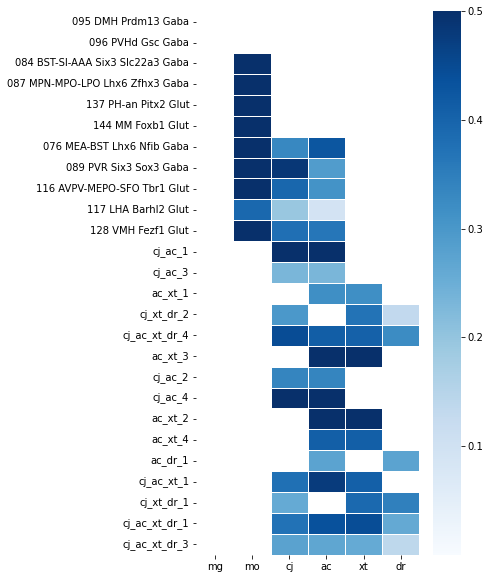

In [53]:
plt.rcParams['font.family'] = 'Helvetica'
plt.figure(figsize=(5, 10))
ax = sns.heatmap(plt_df_samap,cmap = my_cmap,linewidth = .5,vmin = .00001, vmax = .5)
ax.set_facecolor('black')
plt.savefig('../../Figures/Figures_08022026/Mam_Nonmam_Amn_SAMAPscore_average_08042026.svg', bbox_inches='tight',)
plt.savefig('../../Figures/Figures_08022026/Mam_Nonmam_Amn_SAMAPscore_average_08042026.png', bbox_inches='tight', dpi = 300)
plt.savefig('../../Figures/Figures_08022026/Mam_Nonmam_Amn_SAMAPscore_average_08042026.pdf', bbox_inches='tight',)

In [54]:
plt_df_samap.to_csv('../../Nonmammal_mapping_SAMap_08042026.csv')

In [55]:
index_order = [
'095 DMH Prdm13 Gaba',
'096 PVHd Gsc Gaba',
'084 BST-SI-AAA Six3 Slc22a3 Gaba',
'087 MPN-MPO-LPO Lhx6 Zfhx3 Gaba',
'137 PH-an Pitx2 Glut',
'144 MM Foxb1 Glut',
'076 MEA-BST Lhx6 Nfib Gaba',
'089 PVR Six3 Sox3 Gaba',
'116 AVPV-MEPO-SFO Tbr1 Glut',
'117 LHA Barhl2 Glut',
'128 VMH Fezf1 Glut',
'cj_ac_1','cj_ac_3','ac_xt_1','cj_xt_dr_2','cj_ac_xt_dr_4','ac_xt_3','cj_ac_2','cj_ac_4','ac_xt_2','ac_xt_4','ac_dr_1','cj_ac_xt_1','cj_xt_dr_1','cj_ac_xt_dr_1','cj_ac_xt_dr_3',]

In [56]:
plt_df_samap = pd.read_csv('../../Nonmammal_mapping_SAMap_08042026.csv',index_col = 'Unnamed: 0')

In [57]:
for org in plt_df_NT.columns:
    for ct in plt_df_NT.index:
        if org == 'mg' and ct[:3].isdigit():
            plt_df_NT.loc[ct, org] = ct.split(' ')[-1]
        elif plt_df_samap.loc[ct,org] > 0:
            if org == 'mo':
                plt_df_NT.loc[ct,org] = MO_NT.loc[ct,'Neurotransmitter']
            elif org == 'cj':
                plt_df_NT.loc[ct,org] = CJ_NT.loc[ct,'Neurotransmitter']
            elif org == 'ac':
                plt_df_NT.loc[ct,org] = AC_NT.loc[ct,'Neurotransmitter']
            elif org == 'xt':
                plt_df_NT.loc[ct,org] = XT_NT.loc[ct,'Neurotransmitter']
            elif org == 'dr':
                plt_df_NT.loc[ct,org] = DR_NT.loc[ct,'Neurotransmitter']
            else:
                print('error')

In [58]:
plt_df_NT

,mg,mo,cj,ac,xt,dr
095 DMH Prdm13 Gaba,Gaba,NaN,NaN,NaN,NaN,NaN
096 PVHd Gsc Gaba,Gaba,NaN,NaN,NaN,NaN,NaN
084 BST-SI-AAA Six3 Slc22a3 Gaba,Gaba,Gaba,NaN,NaN,NaN,NaN
087 MPN-MPO-LPO Lhx6 Zfhx3 Gaba,Gaba,Gaba,NaN,NaN,NaN,NaN
137 PH-an Pitx2 Glut,Glut,Glut,NaN,NaN,NaN,NaN
144 MM Foxb1 Glut,Glut,Glut,NaN,NaN,NaN,NaN
076 MEA-BST Lhx6 Nfib Gaba,Gaba,Gaba,Gaba,Gaba,NaN,NaN
089 PVR Six3 Sox3 Gaba,Gaba,Gaba,Gaba,Gaba,NaN,NaN
116 AVPV-MEPO-SFO Tbr1 Glut,Glut,Glut,Glut,Glut,NaN,NaN
117 LHA Barhl2 Glut,Glut,Glut,Glut,Glut,NaN,NaN


In [59]:
nt_mapping = {'Gaba-Chol':1,
             'Chol':1,
             'Glut-Chol':1,
             'Glut-Gaba-Dopa':2,
             'Gaba-Dopa':2,
             'Dopa-Gaba':2,
             'Glut-Dopa':2,
             'Dopa':2,
             'Gly':3,
             'Hist':4,
             'Gaba':5,
             'Glut':6,
             'Gaba-Glut':7,
             'Glut-Gaba':7,
             'Gaba-Gly':3,
             'Glut-Gly': 3,
             'Glut-Gaba-Gly':3,
             'Gaba-Hist':4,
             'Hist-Gaba':4,
             'Nora':8,
             'Gaba-Sert':9,
             'Glut-Sert':9,
             'unclear':10,
             'Chol-Gly':11,
             'Sert':9,
             'Glut-Sert-Gly':12,
             'Gaba-Dopa-Sert':9,
             'Glut-Gaba-Hist':4,
             'Glut-Gaba-Sert-Hist':4}

In [60]:
nt_mapping

{'Gaba-Chol': 1,
 'Chol': 1,
 'Glut-Chol': 1,
 'Glut-Gaba-Dopa': 2,
 'Gaba-Dopa': 2,
 'Dopa-Gaba': 2,
 'Glut-Dopa': 2,
 'Dopa': 2,
 'Gly': 3,
 'Hist': 4,
 'Gaba': 5,
 'Glut': 6,
 'Gaba-Glut': 7,
 'Glut-Gaba': 7,
 'Gaba-Gly': 3,
 'Glut-Gly': 3,
 'Glut-Gaba-Gly': 3,
 'Gaba-Hist': 4,
 'Hist-Gaba': 4,
 'Nora': 8,
 'Gaba-Sert': 9,
 'Glut-Sert': 9,
 'unclear': 10,
 'Chol-Gly': 11,
 'Sert': 9,
 'Glut-Sert-Gly': 12,
 'Gaba-Dopa-Sert': 9,
 'Glut-Gaba-Hist': 4,
 'Glut-Gaba-Sert-Hist': 4}

In [61]:
plt_df_NT = plt_df_NT.reindex(index_order)

In [62]:
NT_df_numeric = plt_df_NT.replace(nt_mapping)

In [63]:
NT_df_numeric = NT_df_numeric.reindex(index_order)

In [64]:
custom_colors = ['#73E785','#FCF04B','#820E57','#FF7621','#FF3358','#2B93DF','#0A9964','#03EDFF','#4f2e91ff','black','pink','salmon','maroon','goldenrod']

In [65]:
custom_cmap = LinearSegmentedColormap.from_list('Custom', custom_colors, len(custom_colors))

In [66]:
NT_df_numeric = NT_df_numeric.loc[:,['mg','mo','cj','ac','xt','dr']]

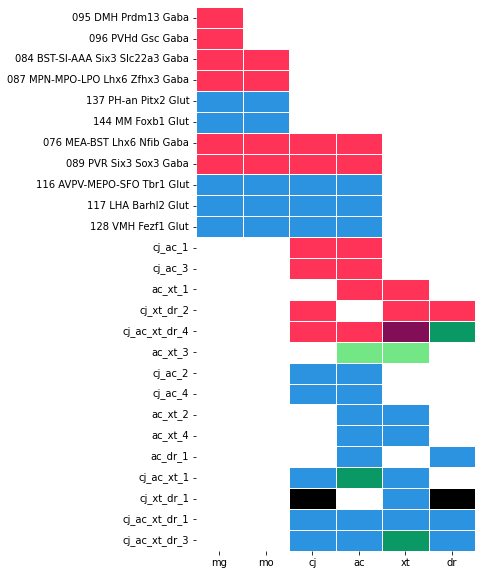

In [68]:
plt.rcParams['font.family'] = 'Helvetica'
plt.figure(figsize=(5, 10))
ax = sns.heatmap(NT_df_numeric,cmap=custom_cmap, vmax = 14, vmin = 1, cbar = False, linewidth = .5)
plt.savefig('../../Figures/Figures_08022026/Mam_nonmam_mapping_NT_08042026.svg',bbox_inches = 'tight')
plt.savefig('../../Figures/Figures_08022026/Mam_nonmam_mapping_NT_08042026.png',dpi = 300,bbox_inches = 'tight')
plt.savefig('../../Figures/Figures_08022026/Mam_nonmam_mapping_NT_08042026.pdf',bbox_inches = 'tight')